# Week 1: Data Cleaning and Exploration

This notebook prepares the telco churn dataset for downstream modeling.

## Goals
- Load the raw dataset
- Check structure and missing values
- Clean and transform key fields
- Create basic churn visualizations
- Export a cleaned dataset for Week 2

## Step 1: Load the Raw Dataset
Import the source CSV and preview the first rows so we can confirm the file loaded correctly.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Inspect the Data
Check the dataset shape, data types, missing values, and summary statistics before cleaning.

In [10]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Step 3: Clean Core Fields
Convert `TotalCharges` to numeric, fill missing values, remove the customer ID, and encode the churn target.

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns=['customerID'], errors='ignore')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## Step 4: Engineer Useful Features
Create a monthly charge proxy and convert selected categorical variables into model-friendly features.

In [12]:
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, columns=['gender', 'MultipleLines', 'InternetService',
                                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV', 'StreamingMovies',
                                  'Contract', 'PaymentMethod'], drop_first=True)

## Step 5: Check Churn Distribution
Review class balance to understand how many customers churn versus stay.

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.73
1    0.27
Name: proportion, dtype: float64


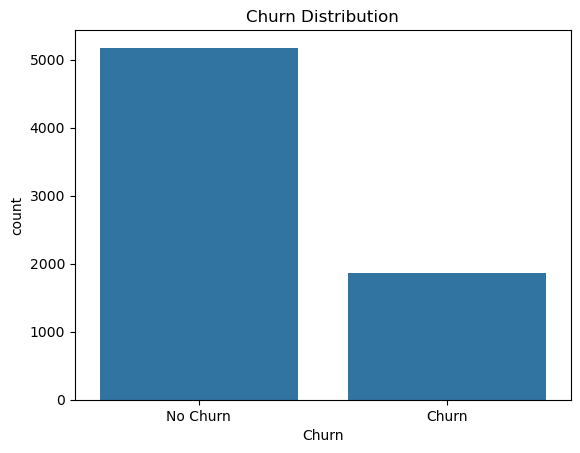

In [13]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(2))

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

## Step 6: Explore Key Numeric Patterns
Compare tenure and charge distributions between churned and non-churned customers.

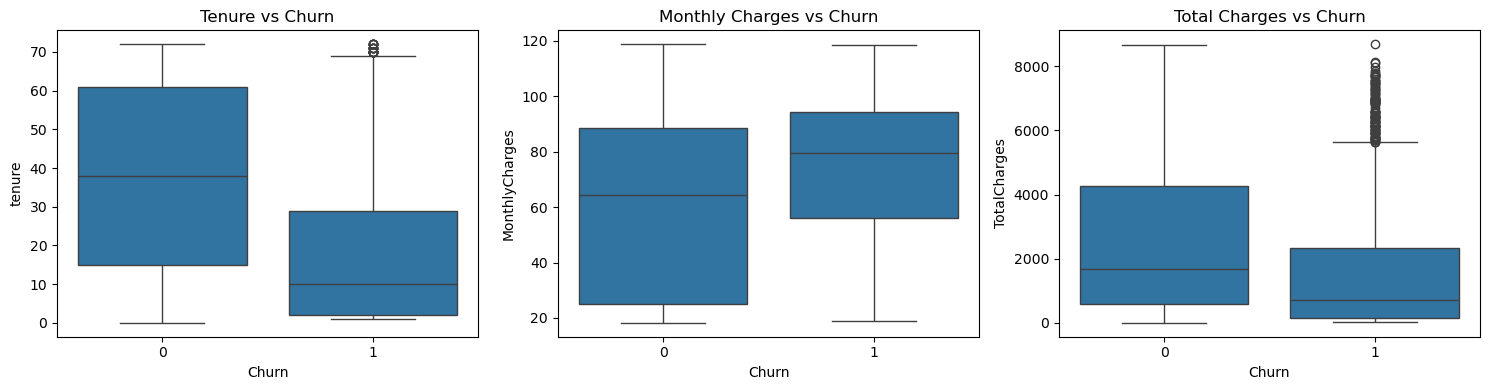

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
axes[0].set_title('Tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2])
axes[2].set_title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

## Step 7: Check Correlations
Look at which features are most positively or negatively associated with churn.

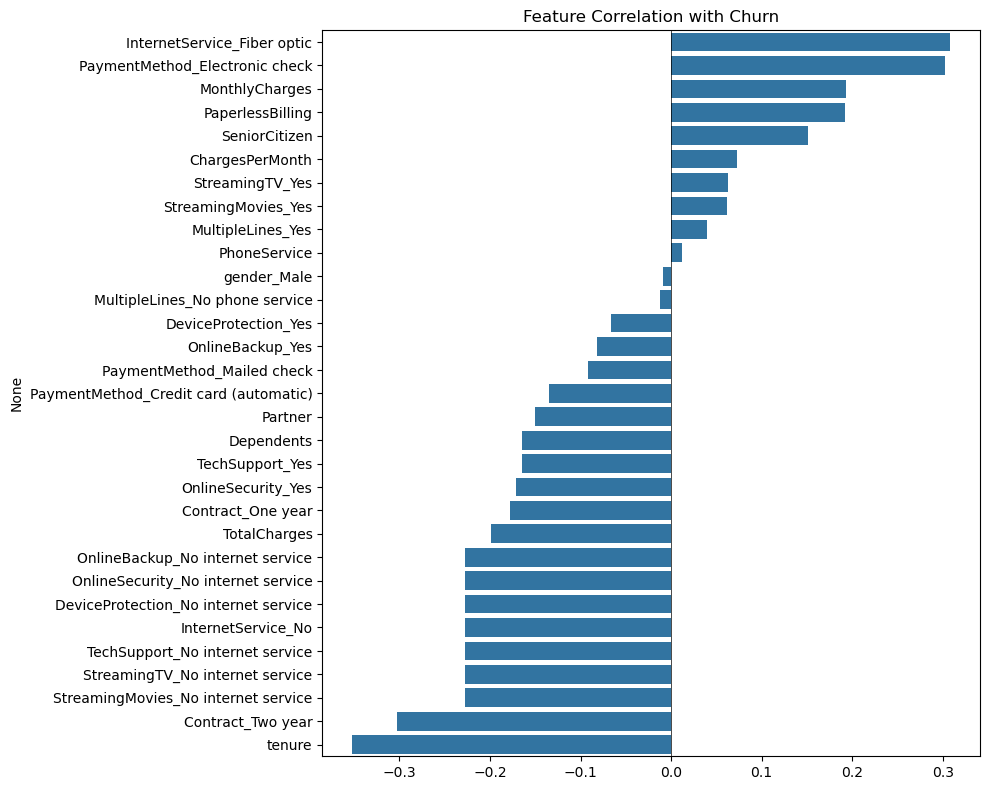

In [15]:
plt.figure(figsize=(10, 8))

corr = df.corr()['Churn'].sort_values(ascending=False).drop('Churn')

sns.barplot(x=corr.values, y=corr.index)
plt.title('Feature Correlation with Churn')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Step 8: Export the Cleaned Dataset
Save the processed dataframe so Week 2 can use a consistent modeling input.

In [16]:
# Export cleaned dataset for downstream modeling
from pathlib import Path

project_root = Path.cwd().resolve()
candidate = project_root
for _ in range(8):
    if (candidate / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv").exists():
        project_root = candidate
        break
    if candidate.parent == candidate:
        break
    candidate = candidate.parent

cleaned_path = project_root / "data" / "cleaned_churn_data.csv"

if "df" not in globals():
    raise ValueError("Expected in-memory dataframe 'df' from previous preprocessing cells.")

df_clean_export = df.copy()

# Ensure key engineered field exists for downstream modeling consistency
if "ChargesPerMonth" not in df_clean_export.columns and {"TotalCharges", "tenure"}.issubset(df_clean_export.columns):
    df_clean_export["ChargesPerMonth"] = df_clean_export["TotalCharges"] / (df_clean_export["tenure"] + 1)

# Enforce numeric dtype on common numeric columns when present
for col in ["TotalCharges", "MonthlyCharges", "tenure", "ChargesPerMonth"]:
    if col in df_clean_export.columns:
        df_clean_export[col] = pd.to_numeric(df_clean_export[col], errors="coerce")

df_clean_export.to_csv(cleaned_path, index=False)
print(f"Saved cleaned dataset: {cleaned_path}")
print(f"Exported shape: {df_clean_export.shape}")
display(df_clean_export.head())

Saved cleaned dataset: /Users/vrushil/Desktop/Temple University/Principle of Data Science/Predictive-Churn-Retention-Analysis-Data-Science-project/data/cleaned_churn_data.csv
Exported shape: (7043, 32)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,14.925000,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,53.985714,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,36.050000,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,40.016304,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,50.550000,...,False,False,False,False,False,False,False,False,True,False
